# Adult Census Income Classification
**Dataset:** Adult Census Income | **Target:** Income >50K or <=50K

## Task 1: Dataset Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../dataset/adult.csv")
print("Shape:", df.shape)
print("Column Names:", df.columns.tolist())
df.head()

Shape: (32561, 15)
Column Names: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print(df.dtypes)
print("Basic Stats:")
df.describe()

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object
Basic Stats:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
print("Target Distribution:")
print(df["income"].value_counts())
print("Missing (?) Values:")
print((df == " ?").sum())

Target Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
Missing (?) Values:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


## Task 2: Data Cleaning

In [5]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

df.replace("?", np.nan, inplace=True)
print("Missing after replace:")
print(df.isnull().sum())

Missing after replace:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [6]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
print("Shape after cleaning:", df.shape)
print("Class balance: ", df["income"].value_counts())

Shape after cleaning: (32537, 15)
Class balance:  income
0    24698
1     7839
Name: count, dtype: int64


## Task 3: Feature Engineering

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df.drop(columns=["fnlwgt", "education"], inplace=True)
le = LabelEncoder()
cat_features = df.select_dtypes(include="object").columns.tolist()
for col in cat_features:
    df[col] = le.fit_transform(df[col])

X = df.drop("income", axis=1)
y = df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Features:", X.columns.tolist())
print("Train/Test split:", X_train.shape, X_test.shape)

Features: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']
Train/Test split: (26029, 12) (6508, 12)


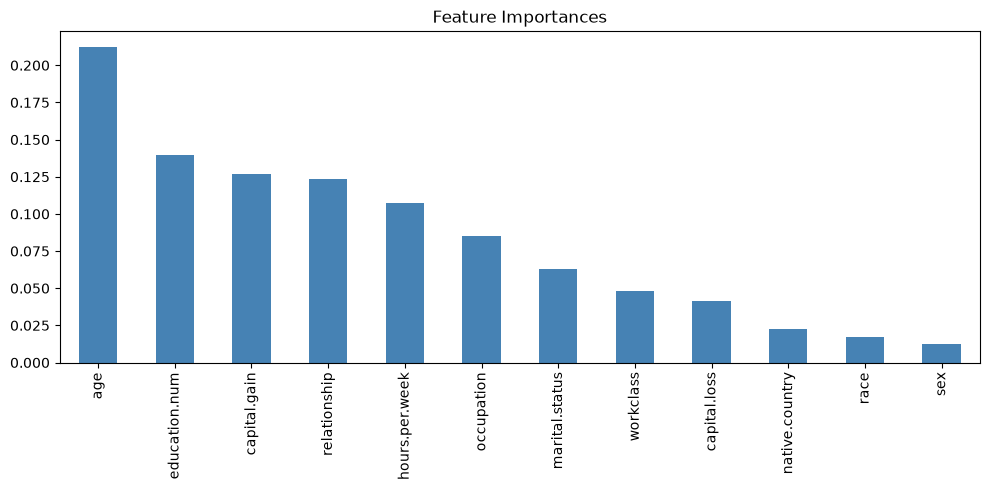

In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_q = RandomForestClassifier(n_estimators=50, random_state=42)
rf_q.fit(X_train, y_train)
importances = pd.Series(rf_q.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind="bar", figsize=(10,5), color="steelblue", title="Feature Importances")
plt.tight_layout(); plt.show()

## Task 4: Model Building

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
}

results = {}
conf_matrices = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1 Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
        "y_pred": y_pred, "y_prob": y_prob,
    }
    conf_matrices[name] = confusion_matrix(y_test, y_pred)
    print(f"{name}: trained")

Logistic Regression: trained
Decision Tree: trained
Random Forest: trained
KNN: trained
SVM: trained


## Task 5: Performance Evaluation

In [10]:
results_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ["y_pred", "y_prob"]}
    for name, r in results.items()
}).T
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8227     0.7070  0.4509    0.5506   0.8504
Decision Tree          0.8506     0.7141  0.6339    0.6716   0.8835
Random Forest          0.8450     0.7066  0.6097    0.6546   0.8874
KNN                    0.8250     0.6531  0.5835    0.6164   0.8430
SVM                    0.8483     0.7619  0.5389    0.6313   0.8846


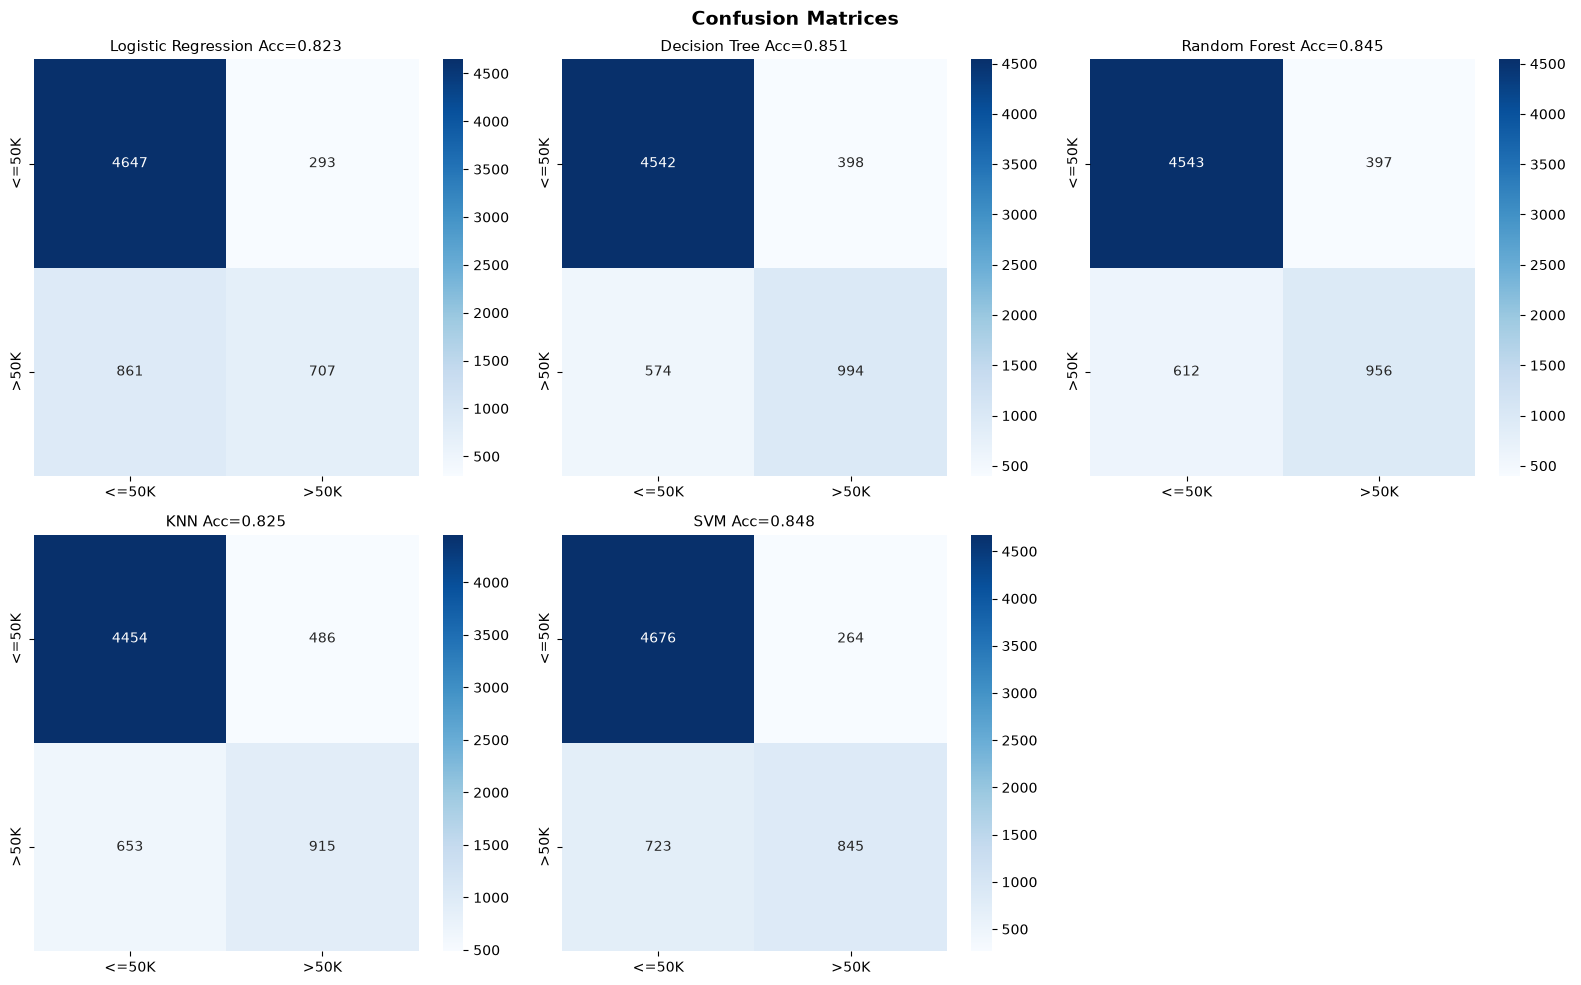

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    axes[idx].set_title(f"{name} Acc={results[name]["Accuracy"]:.3f}", fontsize=11)
axes[5].axis("off")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

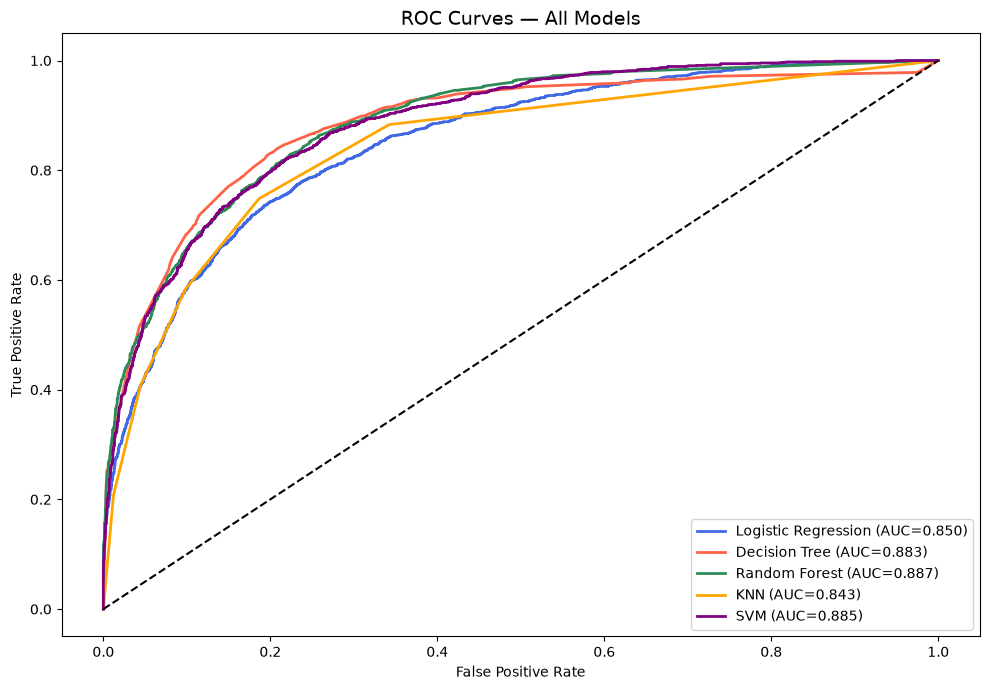

In [12]:
plt.figure(figsize=(10, 7))
colors = ["royalblue", "tomato", "seagreen", "orange", "purple"]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={r["ROC-AUC"]:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontsize=14)
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()